In [4]:
# Import the pandas library 
import pandas as pd

In [5]:
# Load oxygen demand and oxidized nitrogen datasets from CSV files
oxygen_df = pd.read_csv('../data/Oxygen_Demand.csv', sep=';')
nitrate_df = pd.read_csv('../data/oxidized_nitrogen.csv', sep=';')

# Convert 'Sample.Date' column to datetime format and extract the year
oxygen_df['Year'] = pd.to_datetime(oxygen_df['Sample.Date']).dt.year
nitrate_df['Year'] = pd.to_datetime(nitrate_df['Sample.Date']).dt.year

/var/folders/tq/7vkyx62523b_ly0hh2lnbrc80000gn/T/ipykernel_84082/2616130698.py:2: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  oxygen_df = pd.read_csv('../data/Oxygen_Demand.csv', sep=';')
/var/folders/tq/7vkyx62523b_ly0hh2lnbrc80000gn/T/ipykernel_84082/2616130698.py:3: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  nitrate_df = pd.read_csv('../data/oxidized_nitrogen.csv', sep=';')


In [6]:
# Load station metadata to access country information for each monitoring station
station_metadata = pd.read_csv('../data/GEMStat_station_metadata.csv', sep=';', encoding='ISO-8859-1')

# Merge oxygen dataset with station metadata to add the 'Country Name' column
# Only the relevant columns ('GEMS Station Number' and 'Country Name') are used from the metadata
oxygen_df = pd.merge(oxygen_df, station_metadata[['GEMS Station Number', 'Country Name']], how='left', left_on='GEMS.Station.Number', right_on='GEMS Station Number')

# Merge nitrate dataset with station metadata to add the 'Country Name' column
nitrate_df = pd.merge(nitrate_df, station_metadata[['GEMS Station Number', 'Country Name']], how='left', left_on='GEMS.Station.Number', right_on='GEMS Station Number')


In [7]:
# Group the oxygen dataset by country and year, then calculate the average oxygen demand
oxygen_avg = oxygen_df.groupby(['Country Name', 'Year'])['Value'].mean().reset_index()

# Group the nitrate dataset by country and year, then calculate the average oxidized nitrogen level
nitrate_avg = nitrate_df.groupby(['Country Name', 'Year'])['Value'].mean().reset_index()

In [8]:
# Merge the oxygen and nitrate average datasets on both 'Country Name' and 'Year'
# the two pollutants side-by-side for each country-year pair
# Suffixes added to distinguish between oxygen and nitrate values
merged_df = pd.merge(oxygen_avg, nitrate_avg, on=['Country Name', 'Year'], suffixes=('_oxygen', '_nitrate'))

# Display the first few rows of the merged DataFrame to confirm it worked
print(merged_df.head())


  Country Name  Year  Value_oxygen  Value_nitrate
0    Argentina  2011     14.000000       1.865000
1    Argentina  2012      3.625000       1.928750
2    Argentina  2013      8.875000       1.645000
3    Argentina  2021      9.000000       0.657443
4      Austria  2014      2.037671       3.376383


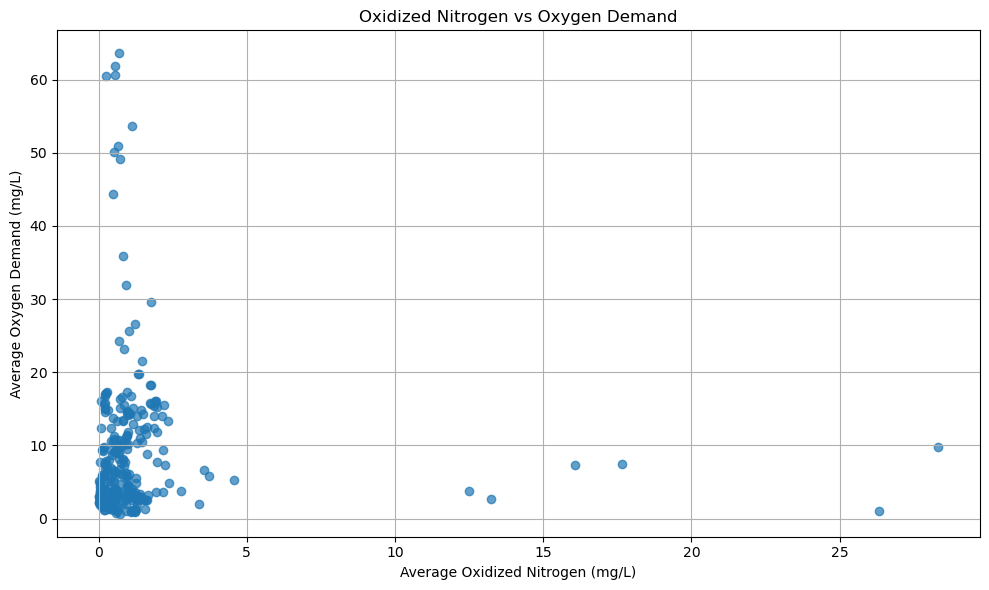

In [9]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a scatter plot to show the relationship between oxidized nitrogen and oxygen demand
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Value_nitrate'], merged_df['Value_oxygen'], alpha=0.7)
plt.title('Oxidized Nitrogen vs Oxygen Demand')
plt.xlabel('Average Oxidized Nitrogen (mg/L)')
plt.ylabel('Average Oxygen Demand (mg/L)')
plt.grid(True)
plt.tight_layout()
plt.show()


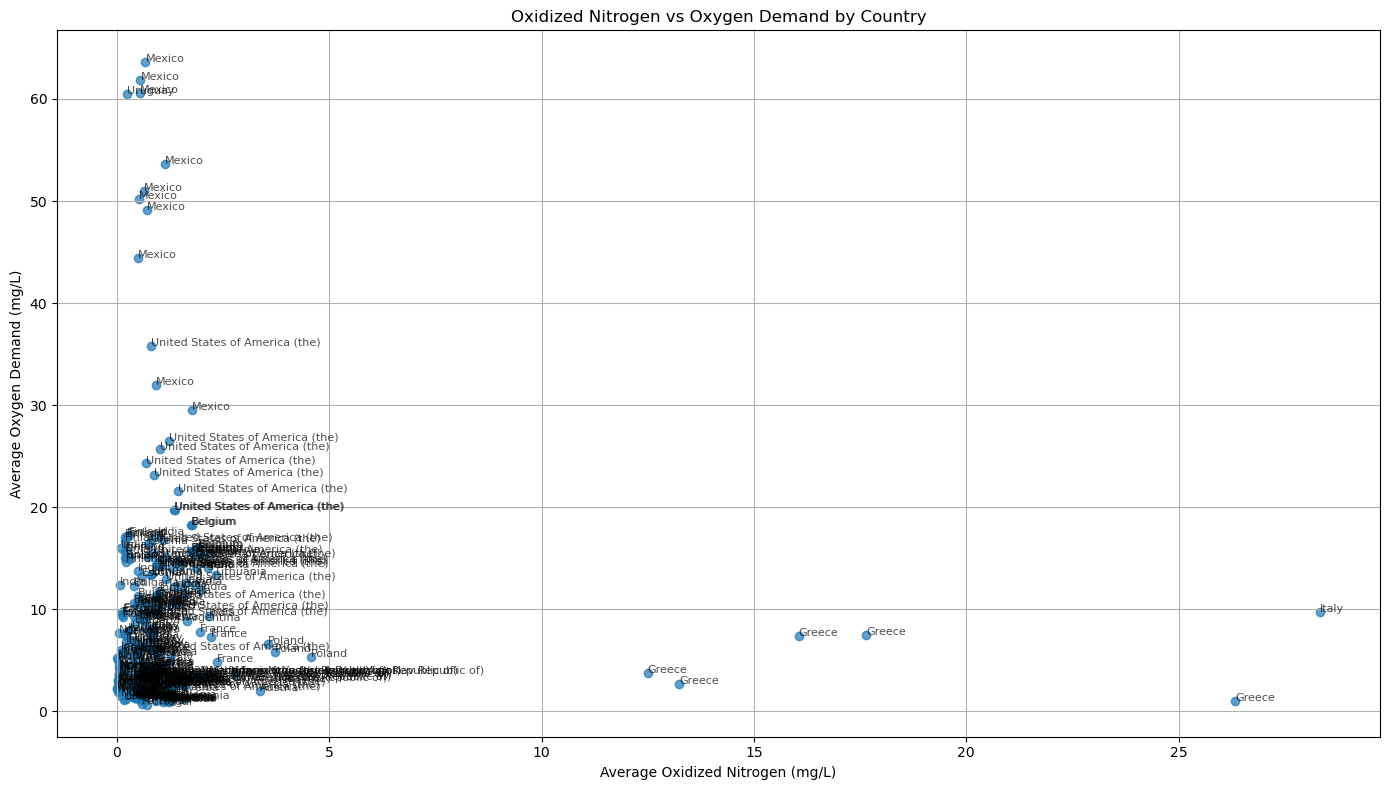

In [ ]:
plt.figure(figsize=(14, 8))

# Create a scatter plot to visualize the relationship between oxidized nitrogen and oxygen demand
plt.scatter(merged_df['Value_nitrate'], merged_df['Value_oxygen'], alpha=0.7)

# Annotate each point with the corresponding country name
# loop places text labels at each data point
for i in range(len(merged_df)):
    plt.text(merged_df['Value_nitrate'][i], merged_df['Value_oxygen'][i], merged_df['Country Name'][i], fontsize=8, alpha=0.7)

# Add descriptive title and axis labels
plt.title('Oxidized Nitrogen vs Oxygen Demand by Country')
plt.xlabel('Average Oxidized Nitrogen (mg/L)')
plt.ylabel('Average Oxygen Demand (mg/L)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Identify the top 5 countries with the highest average oxygen demand
top_oxygen = merged_df.sort_values(by='Value_oxygen', ascending=False).head(5)

# Identify the top 5 countries with the highest average oxidized nitrogen levels
top_nitrogen = merged_df.sort_values(by='Value_nitrate', ascending=False).head(5)

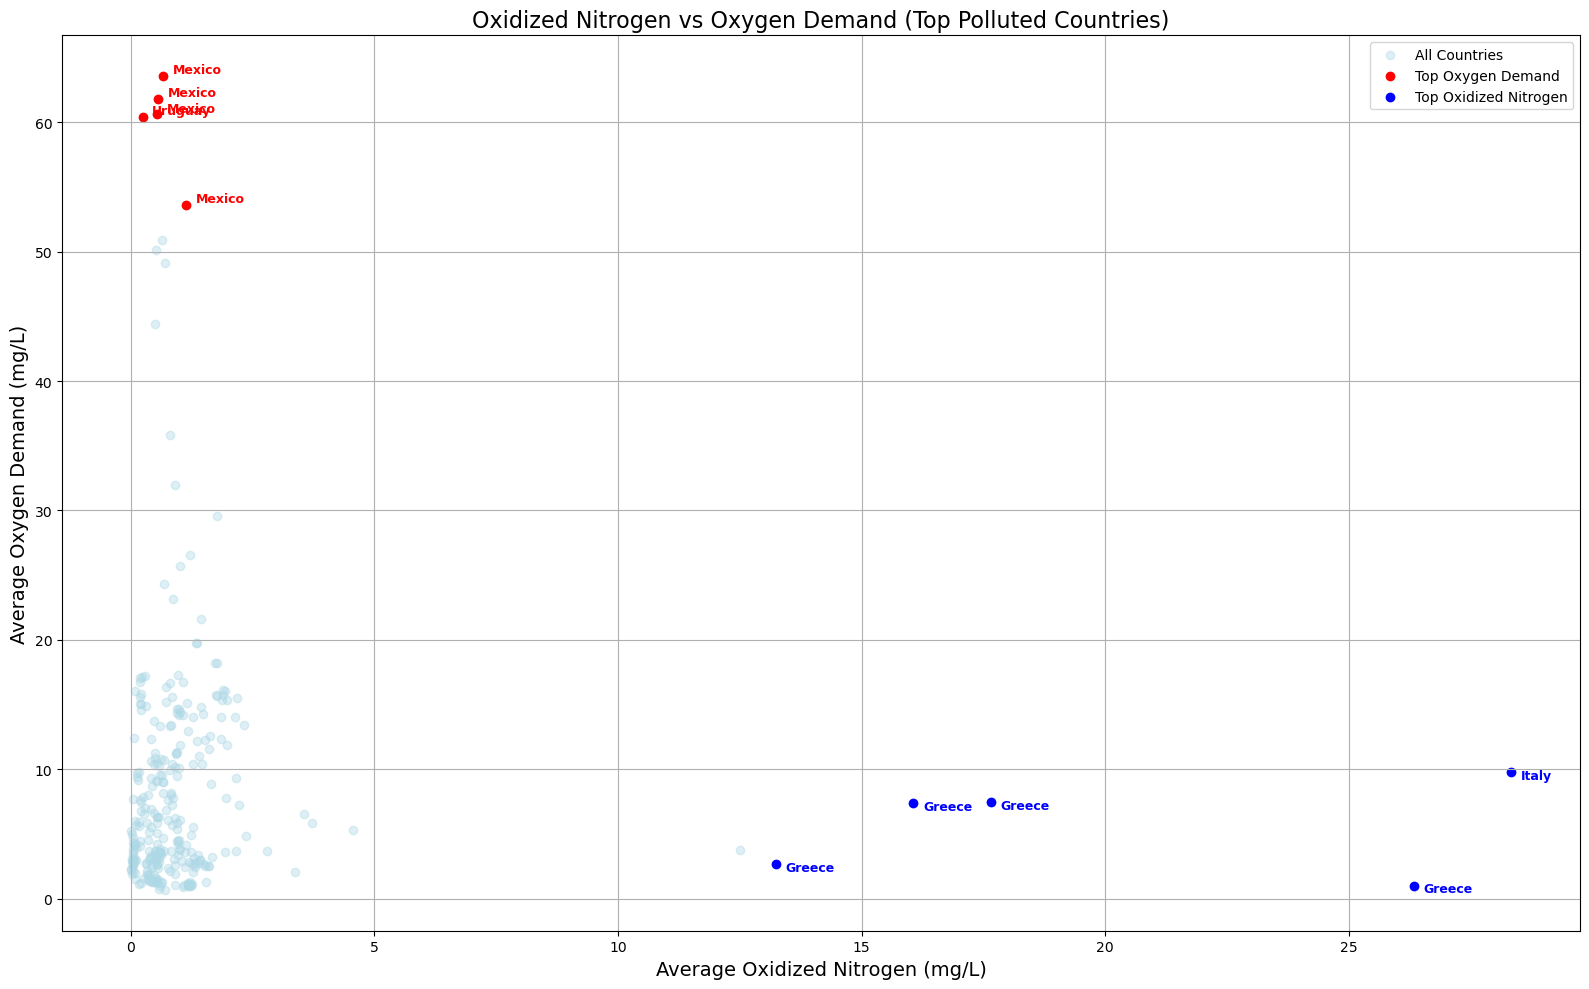

In [ ]:
# Create a large figure for better visibility of all points and labels
plt.figure(figsize=(16, 10))

# Plot all countries as light blue dots to provide background context
plt.scatter(merged_df['Value_nitrate'], 
            merged_df['Value_oxygen'], 
            alpha=0.4, 
            label='All Countries', 
            color='lightblue')

# Highlight the top 5 countries with the highest oxygen demand
plt.scatter(top_oxygen['Value_nitrate'], 
            top_oxygen['Value_oxygen'], 
            color='red', 
            label='Top Oxygen Demand')

# Highlight the top 5 countries with the highest oxidized nitrogen levels
plt.scatter(top_nitrogen['Value_nitrate'], 
            top_nitrogen['Value_oxygen'], 
            color='blue', 
            label='Top Oxidized Nitrogen')

# Add red labels for countries with highest oxygen demand
for i in range(len(top_oxygen)):
    # Slight right offset
    plt.text(top_oxygen['Value_nitrate'].iloc[i] + 0.2,
             # Slight upward offset
             top_oxygen['Value_oxygen'].iloc[i] + 0.2,
             top_oxygen['Country Name'].iloc[i],
             fontsize=9, weight='bold', color='red')

# Add blue labels for countries with highest nitrate levels
for i in range(len(top_nitrogen)):
    # Slight right offset
    plt.text(top_nitrogen['Value_nitrate'].iloc[i] + 0.2,
             # slightly downward offset
             top_nitrogen['Value_oxygen'].iloc[i] - 0.5,  
             top_nitrogen['Country Name'].iloc[i],
             fontsize=9, weight='bold', color='blue')

# Title and labels
plt.title('Oxidized Nitrogen vs Oxygen Demand (Top Polluted Countries)', fontsize=16)
plt.xlabel('Average Oxidized Nitrogen (mg/L)', fontsize=14)
plt.ylabel('Average Oxygen Demand (mg/L)', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

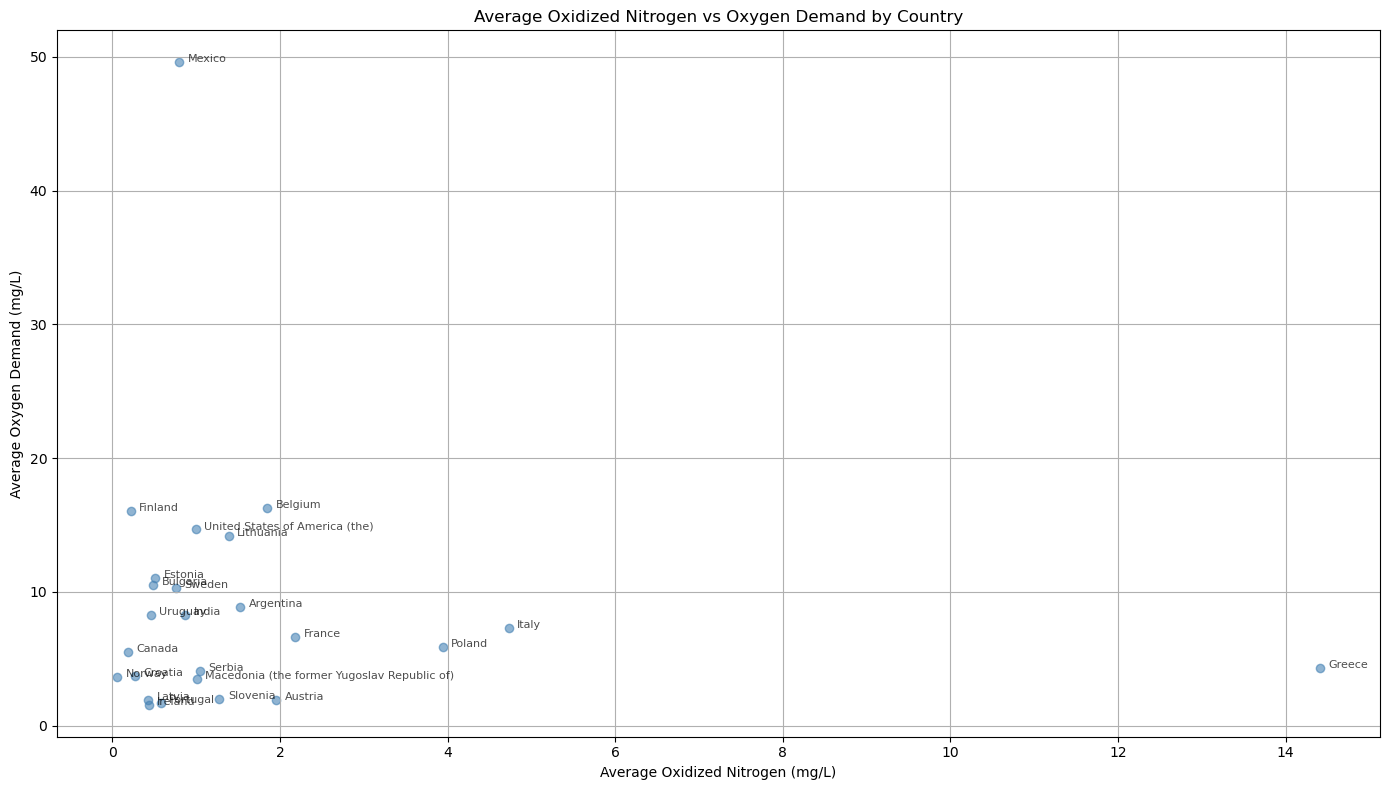

In [ ]:

# Group the merged_df by country to get average values
aggregated_df = merged_df.groupby('Country Name')[['Value_nitrate', 'Value_oxygen']].mean().reset_index()

# Create a scatter plot to visualize the relationship between nitrate and oxygen demand at the country level
plt.figure(figsize=(14, 8))
plt.scatter(aggregated_df['Value_nitrate'], aggregated_df['Value_oxygen'], alpha=0.6, color='steelblue')

# Annotate each point with the corresponding country name
for i in range(len(aggregated_df)):
    plt.text(aggregated_df['Value_nitrate'][i] + 0.1,
             aggregated_df['Value_oxygen'][i],
             aggregated_df['Country Name'][i],
             fontsize=8, alpha=0.7)

# Add plot labels and grid
plt.title('Average Oxidized Nitrogen vs Oxygen Demand by Country')
plt.xlabel('Average Oxidized Nitrogen (mg/L)')
plt.ylabel('Average Oxygen Demand (mg/L)')
plt.grid(True)
# Optimize spacing to prevent text from getting cut off
plt.tight_layout()
# Display the final plot
plt.show()


In [ ]:
# Install Plotly for creating interactive visualizations
!pip install plotly

    extract-msg (<=0.29.*)
                 ~~~~~~~^


In [ ]:
# Import Plotly for interactive plotting
import plotly.express as px

# for interactive scatter plot to compare oxidized nitrogen and oxygen demand by country
fig = px.scatter(
    # Data source: average values per country
    aggregated_df,
    x='Value_nitrate',
    y='Value_oxygen',
    text='Country Name',
    title='Average Oxidized Nitrogen vs Oxygen Demand',
    labels={'Value_nitrate': 'Oxidized Nitrogen (mg/L)', 'Value_oxygen': 'Oxygen Demand (mg/L)'},
)

# Customize marker and text appearance
fig.update_traces(
    textposition='top right',
    marker=dict(size=8),
    textfont=dict(size=9),
    hovertemplate='<b>%{text}</b><br>Nitrate: %{x}<br>Oxygen: %{y}<extra></extra>'
)

# Update layout: axis ranges, background, fonts, and title styling
fig.update_layout(
    xaxis=dict(range=[-1, aggregated_df['Value_nitrate'].max() + 3]),
    yaxis=dict(range=[0, aggregated_df['Value_oxygen'].max() + 10]),
    plot_bgcolor='rgba(240,240,255,0.95)',
    title_font_size=22,
    font=dict(family="Arial", size=14)
)

# Display the interactive plot
fig.show()

# Save as an HTML
fig.write_html("../visualizations/nitrogen_vs_oxygen.html", include_plotlyjs='cdn')



In [25]:

import numpy as np
import os

# Add small random noise (jitter) to prevent overlapping points in the scatter plot
# to improve label clarity and visual separation for countries with similar values
np.random.seed(42)
aggregated_df['x_jittered'] = aggregated_df['Value_nitrate'] + np.random.normal(0, 0.05, size=len(aggregated_df))
aggregated_df['y_jittered'] = aggregated_df['Value_oxygen'] + np.random.normal(0, 0.05, size=len(aggregated_df))

# Identify specific countries to highlight
highlight_countries = ['Mexico', 'Greece']
aggregated_df['highlight'] = aggregated_df['Country Name'].apply(lambda x: 'Highlighted' if x in highlight_countries else 'Other')

# Plot
fig = px.scatter(
    aggregated_df,
    x='x_jittered',
    y='y_jittered',
    color='highlight',
    hover_name='Country Name',
    title='Average Oxidized Nitrogen vs Oxygen Demand',
    labels={
        'x_jittered': 'Oxidized Nitrogen (mg/L)',
        'y_jittered': 'Oxygen Demand (mg/L)',
        'highlight': ''
    },
    color_discrete_map={'Highlighted': 'crimson', 'Other': 'steelblue'}
)

# Customize marker appearance and hover text
fig.update_traces(
    marker=dict(size=10, line=dict(width=0.5, color='gray')),
    hovertemplate='<b>%{hovertext}</b><br>Nitrogen: %{x:.2f} mg/L<br>Oxygen: %{y:.2f} mg/L<extra></extra>'
)

# Update layout: axis ranges, background, legend, and font
fig.update_layout(
    xaxis=dict(range=[-0.5, aggregated_df['x_jittered'].max() + 2]),
    yaxis=dict(range=[0, aggregated_df['y_jittered'].max() + 10]),
    font=dict(family="Arial", size=14),
    plot_bgcolor='rgba(245, 245, 255, 0.9)',
    legend=dict(title=None, orientation='h', x=0.5, xanchor='center', y=-0.2),
    hoverlabel=dict(font_size=14)
)

# Display
fig.show()
fig.write_html("../visualizations/nitrogen_vs_oxygen_cleaned.html", include_plotlyjs='cdn')



In [ ]:
# Print the list of column names in the aggregated DataFrame
print(aggregated_df.columns.tolist())

['Country Name', 'Value_nitrate', 'Value_oxygen', 'x_jittered', 'y_jittered', 'highlight']


In [ ]:
# Install pycountry library for standardized country name 
pip install pycountry

Note: you may need to restart the kernel to use updated packages.


    extract-msg (<=0.29.*)
                 ~~~~~~~^


In [ ]:
# Import pycountry to access standardized country codes
import pycountry

# Define a function to convert country names to ISO 3-letter codes
def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except LookupError:
        return None

# Apply the ISO code mapping to the 'Country Name' column
aggregated_df['ISO3'] = aggregated_df['Country Name'].apply(get_iso3)


In [ ]:
# Create a choropleth map using ISO3 country codes and average oxidized nitrogen values
fig_choropleth = px.choropleth(
    # Data source: country-level aggregated data
    aggregated_df,
    locations='ISO3',
    color='Value_nitrate',
    hover_name='Country Name',
    color_continuous_scale='Viridis',
    title='Average Oxidized Nitrogen Concentration by Country (mg/L)',
)

# Update layout settings for map appearance
fig_choropleth.update_layout(
    # Remove map border frame + show coastlines for geographic reference
    geo=dict(showframe=False, showcoastlines=True),
    height=600
)

# Save the interactive map as an HTML file for sharing or embedding
fig_choropleth.write_html("../visualizations/choropleth_nitrogen.html", include_plotlyjs='cdn')


In [ ]:
# Build a choropleth map to visualize average oxidized nitrogen levels by country
fig_choropleth = px.choropleth(
    aggregated_df,
    locations='ISO3',  # This must be 3-letter country ISO codes
    color='Value_nitrate',
    hover_name='Country Name',
    color_continuous_scale='Viridis',
    title='Average Oxidized Nitrogen Concentration by Country (mg/L)',
)

# Customize the map's geographic layout and appearance
fig_choropleth.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    showland=True,
    landcolor="LightGray"
)

# Display the interactive map in notebook or browser
fig_choropleth.show()
# Save to HTML
fig_choropleth.write_html("../visualizations/choropleth_nitrogen.html", include_plotlyjs='cdn')


In [ ]:
# Create a geographic bubble map to visualize two pollutants:
# - Bubble size represents oxidized nitrogen levels
# - Color intensity represents oxygen demand levels
fig_bubble = px.scatter_geo(
    # DataFrame with aggregated country-level values
    aggregated_df,
    locations='ISO3',  
    color='Value_oxygen',
    size='Value_nitrate',
    hover_name='Country Name',
    projection='natural earth',
    title='Nitrogen Size and Oxygen Demand Color (mg/L)',
    color_continuous_scale='Bluered'
)

# Customize the map appearance: coastlines, land, projection
fig_bubble.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    showland=True,
    landcolor="LightGray"
)
# Save to HTML
fig_bubble.write_html("../visualizations/bubble_map_nitrogen_oxygen.html", include_plotlyjs='cdn')


In [22]:
fig_bubble.show()

In [ ]:
# Save the Plotly figure as an interactive HTML file
fig.write_html(
    "../visualizations/nitrogen_vs_oxygen_cleaned.html",
    include_plotlyjs='cdn',
    full_html=True,
    config={"responsive": True},
    default_width='100%',
    default_height=600  # or even 700 if needed
)


# Forecasting

In [ ]:
# install prophet for forecast
pip install prophet

Note: you may need to restart the kernel to use updated packages.


    extract-msg (<=0.29.*)
                 ~~~~~~~^


In [ ]:
# Load raw oxidized nitrogen and oxygen demand datasets
nitrate_raw = pd.read_csv('../data/oxidized_nitrogen.csv', sep=';')
oxygen_raw = pd.read_csv('../data/Oxygen_Demand.csv', sep=';')

# Convert 'Sample.Date' column to datetime format, coercing invalid entries to NaT
nitrate_raw['Sample.Date'] = pd.to_datetime(nitrate_raw['Sample.Date'], errors='coerce')
oxygen_raw['Sample.Date'] = pd.to_datetime(oxygen_raw['Sample.Date'], errors='coerce')

# Drop rows that are missing values (date or measurement)
nitrate_clean = nitrate_raw.dropna(subset=['Sample.Date', 'Value'])
oxygen_clean = oxygen_raw.dropna(subset=['Sample.Date', 'Value'])

# Group by date and compute the daily average for each pollutant
nitrate_df = nitrate_clean.groupby('Sample.Date')['Value'].mean().reset_index()
oxygen_df = oxygen_clean.groupby('Sample.Date')['Value'].mean().reset_index()

# Rename columns to match Prophet's expected format: 
# 'ds' for datetime and 'y' for the value to forecast
nitrate_df.columns = ['ds', 'y']
oxygen_df.columns = ['ds', 'y']


/var/folders/tq/7vkyx62523b_ly0hh2lnbrc80000gn/T/ipykernel_84082/368926394.py:2: DtypeWarning:

Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.

/var/folders/tq/7vkyx62523b_ly0hh2lnbrc80000gn/T/ipykernel_84082/368926394.py:3: DtypeWarning:

Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.



13:37:28 - cmdstanpy - INFO - Chain [1] start processing
13:37:29 - cmdstanpy - INFO - Chain [1] done processing
13:37:29 - cmdstanpy - INFO - Chain [1] start processing
13:37:30 - cmdstanpy - INFO - Chain [1] done processing
/opt/miniconda3/envs/SP/lib/python3.11/site-packages/prophet/forecaster.py:1854: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



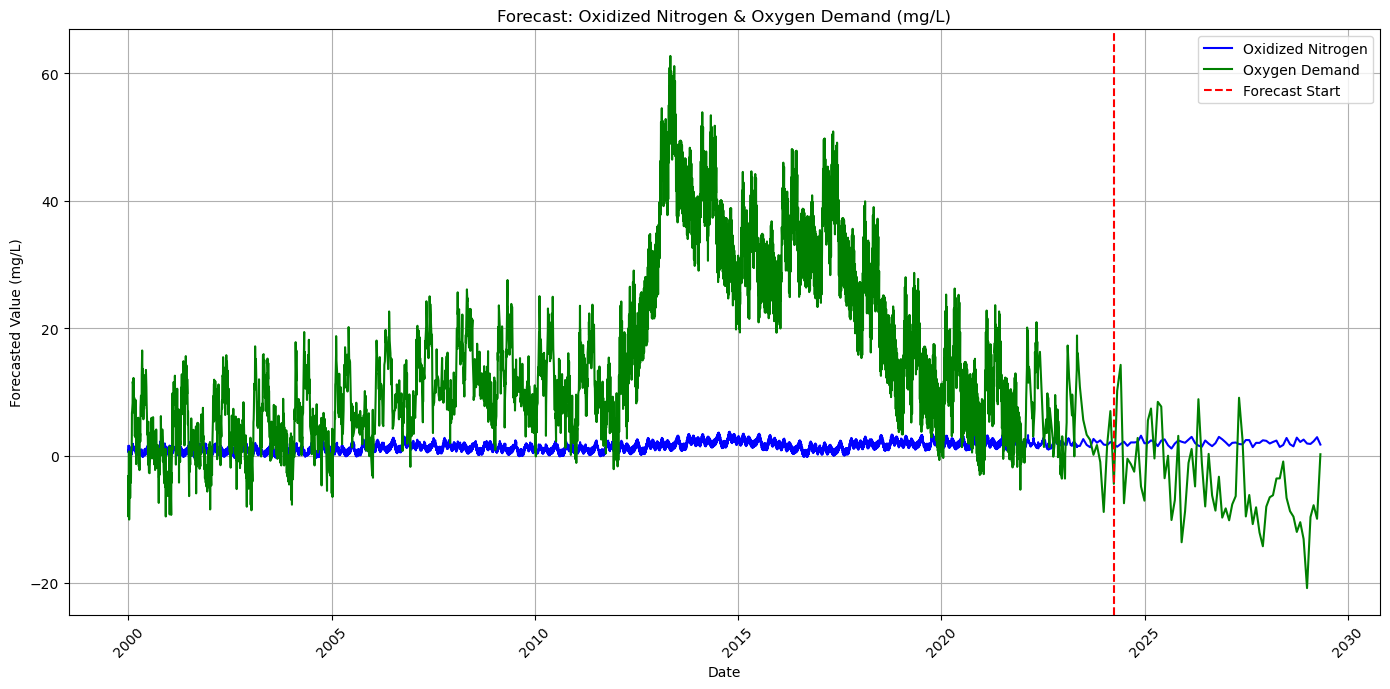

In [28]:
# Import Prophet for time series forecasting
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# Filter the datasets to include only data from the year 2000 onward
nitrate_df = nitrate_df[nitrate_df['ds'] >= '2000-01-01']
oxygen_df = oxygen_df[oxygen_df['ds'] >= '2000-01-01']

# Initialize and fit Prophet models for each pollutant
model_nitrogen = Prophet()
model_nitrogen.fit(nitrate_df)

model_oxygen = Prophet()
model_oxygen.fit(oxygen_df)

# Define future time frames: forecast until the year 2030 (in monthly steps)
years_to_forecast = 2030 - 2024  # Number of years from now until 2030 (adjust if needed)
months_to_forecast = years_to_forecast * 12  # Convert to months

# Generate future dates for prediction
future_nitrogen = model_nitrogen.make_future_dataframe(periods=months_to_forecast, freq='M')
future_oxygen = model_oxygen.make_future_dataframe(periods=months_to_forecast, freq='M')

# Generate forecasts
forecast_nitrogen = model_nitrogen.predict(future_nitrogen)
forecast_oxygen = model_oxygen.predict(future_oxygen)

# Plot the forecasted values for both pollutants
plt.figure(figsize=(14, 7))

# Plot forecasted nitrogen
plt.plot(forecast_nitrogen['ds'], forecast_nitrogen['yhat'], label='Oxidized Nitrogen', color='blue')

# Plot forecasted oxygen demand
plt.plot(forecast_oxygen['ds'], forecast_oxygen['yhat'], label='Oxygen Demand', color='green')

# Mark the start of the forecast (adjust date as needed based on actual last training date)
plt.axvline(x=datetime.datetime(2024, 4, 1), color='red', linestyle='--', label='Forecast Start')  # whenever training data ends

# Add legend to differentiate lines
plt.legend()

# X-axis formatting
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Add plot title and labels
plt.title('Forecast: Oxidized Nitrogen & Oxygen Demand (mg/L)')
plt.xlabel('Date')
plt.ylabel('Forecasted Value (mg/L)')
plt.legend()

# Add grid and layout adjustments
plt.grid(True)
plt.tight_layout()

# Display the plot
plt.show()

In [33]:
import pandas as pd
import plotly.graph_objects as go
from prophet import Prophet

# load and clean actual data
nitrate_raw = pd.read_csv('../data/oxidized_nitrogen.csv', sep=';', low_memory=False)
oxygen_raw = pd.read_csv('../data/Oxygen_Demand.csv', sep=';', low_memory=False)

# Convert date column and drop missing values
nitrate_raw['Sample.Date'] = pd.to_datetime(nitrate_raw['Sample.Date'], errors='coerce')
oxygen_raw['Sample.Date'] = pd.to_datetime(oxygen_raw['Sample.Date'], errors='coerce')

nitrate_clean = nitrate_raw.dropna(subset=['Sample.Date', 'Value'])
oxygen_clean = oxygen_raw.dropna(subset=['Sample.Date', 'Value'])

# Group by date and average daily values
nitrate_df = nitrate_clean.groupby('Sample.Date')['Value'].mean().reset_index()
oxygen_df = oxygen_clean.groupby('Sample.Date')['Value'].mean().reset_index()

# Rename columns to Prophet format
nitrate_df.columns = ['ds', 'y']
oxygen_df.columns = ['ds', 'y']

# Filter for data from 2000 onwards
nitrate_df = nitrate_df[nitrate_df['ds'] >= '2000-01-01']
oxygen_df = oxygen_df[oxygen_df['ds'] >= '2000-01-01']

# Train Prophet models 
model_nitrogen = Prophet()
model_nitrogen.fit(nitrate_df)

model_oxygen = Prophet()
model_oxygen.fit(oxygen_df)

# Forecast the next 6 years (72 months)
future_nitrogen = model_nitrogen.make_future_dataframe(periods=72, freq='M')
future_oxygen = model_oxygen.make_future_dataframe(periods=72, freq='M')

forecast_nitrogen = model_nitrogen.predict(future_nitrogen)
forecast_oxygen = model_oxygen.predict(future_oxygen)

# Plot using Plotly 
fig = go.Figure()

# Nitrogen line and confidence interval
fig.add_trace(go.Scatter(x=forecast_nitrogen['ds'], y=forecast_nitrogen['yhat'],
                         mode='lines', name='Oxidized Nitrogen (mg/L)', line=dict(color='blue'), yaxis='y1'))

fig.add_trace(go.Scatter(x=forecast_nitrogen['ds'], y=forecast_nitrogen['yhat_upper'],
                         mode='lines', line=dict(width=0), showlegend=False))

fig.add_trace(go.Scatter(x=forecast_nitrogen['ds'], y=forecast_nitrogen['yhat_lower'],
                         mode='lines', fill='tonexty', line=dict(width=0),
                         fillcolor='rgba(0,0,255,0.1)', name='Nitrogen Range', yaxis='y1'))

# Oxygen line and confidence interval
fig.add_trace(go.Scatter(x=forecast_oxygen['ds'], y=forecast_oxygen['yhat'],
                         mode='lines', name='Oxygen Demand (mg/L)', line=dict(color='green'), yaxis='y2'))

fig.add_trace(go.Scatter(x=forecast_oxygen['ds'], y=forecast_oxygen['yhat_upper'],
                         mode='lines', line=dict(width=0), showlegend=False))

fig.add_trace(go.Scatter(x=forecast_oxygen['ds'], y=forecast_oxygen['yhat_lower'],
                         mode='lines', fill='tonexty', line=dict(width=0),
                         fillcolor='rgba(0,255,0,0.1)', name='Oxygen Range', yaxis='y2'))

# Vertical line showing forecast start
fig.add_shape(
    type='line',
    x0='2024-01-01', x1='2024-01-01',
    y0=0, y1=1,
    xref='x', yref='paper',
    line=dict(color='red', width=2, dash='dash')
)

fig.add_annotation(
    x='2024-01-01', y=1, xref='x', yref='paper',
    text='Forecast Start',
    showarrow=False,
    font=dict(color='red')
)

# Layout 
fig.update_layout(
    title=dict(
        text="Forecast: Oxidized Nitrogen and Oxygen Demand (mg/L)",
        y=0.98,
        x=0.5,
        xanchor='center',
        yanchor='top',
        font=dict(size=20)
    ),
    margin=dict(t=140),
    legend=dict(
        orientation="h",
        y=0.9,
        x=0.5,
        xanchor="center",
        font=dict(size=12)
    ),
    xaxis_title='Date',
    yaxis=dict(
        title=dict(text='Oxidized Nitrogen (mg/L)', font=dict(color='blue')),
        tickfont=dict(color='blue')
    ),
    yaxis2=dict(
        title=dict(text='Oxygen Demand (mg/L)', font=dict(color='green')),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right'
    ),
    template='plotly_white',
    width=1000,
    height=600
)

# Save the chart to an HTML file
fig.write_html("../visualizations/forecast_nitrogen_oxygen.html")


13:50:16 - cmdstanpy - INFO - Chain [1] start processing
13:50:17 - cmdstanpy - INFO - Chain [1] done processing
13:50:17 - cmdstanpy - INFO - Chain [1] start processing
13:50:18 - cmdstanpy - INFO - Chain [1] done processing
/opt/miniconda3/envs/SP/lib/python3.11/site-packages/prophet/forecaster.py:1854: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



13:50:24 - cmdstanpy - INFO - Chain [1] start processing
13:50:24 - cmdstanpy - INFO - Chain [1] done processing
13:50:25 - cmdstanpy - INFO - Chain [1] start processing
13:50:25 - cmdstanpy - INFO - Chain [1] done processing
/opt/miniconda3/envs/SP/lib/python3.11/site-packages/prophet/forecaster.py:1854: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



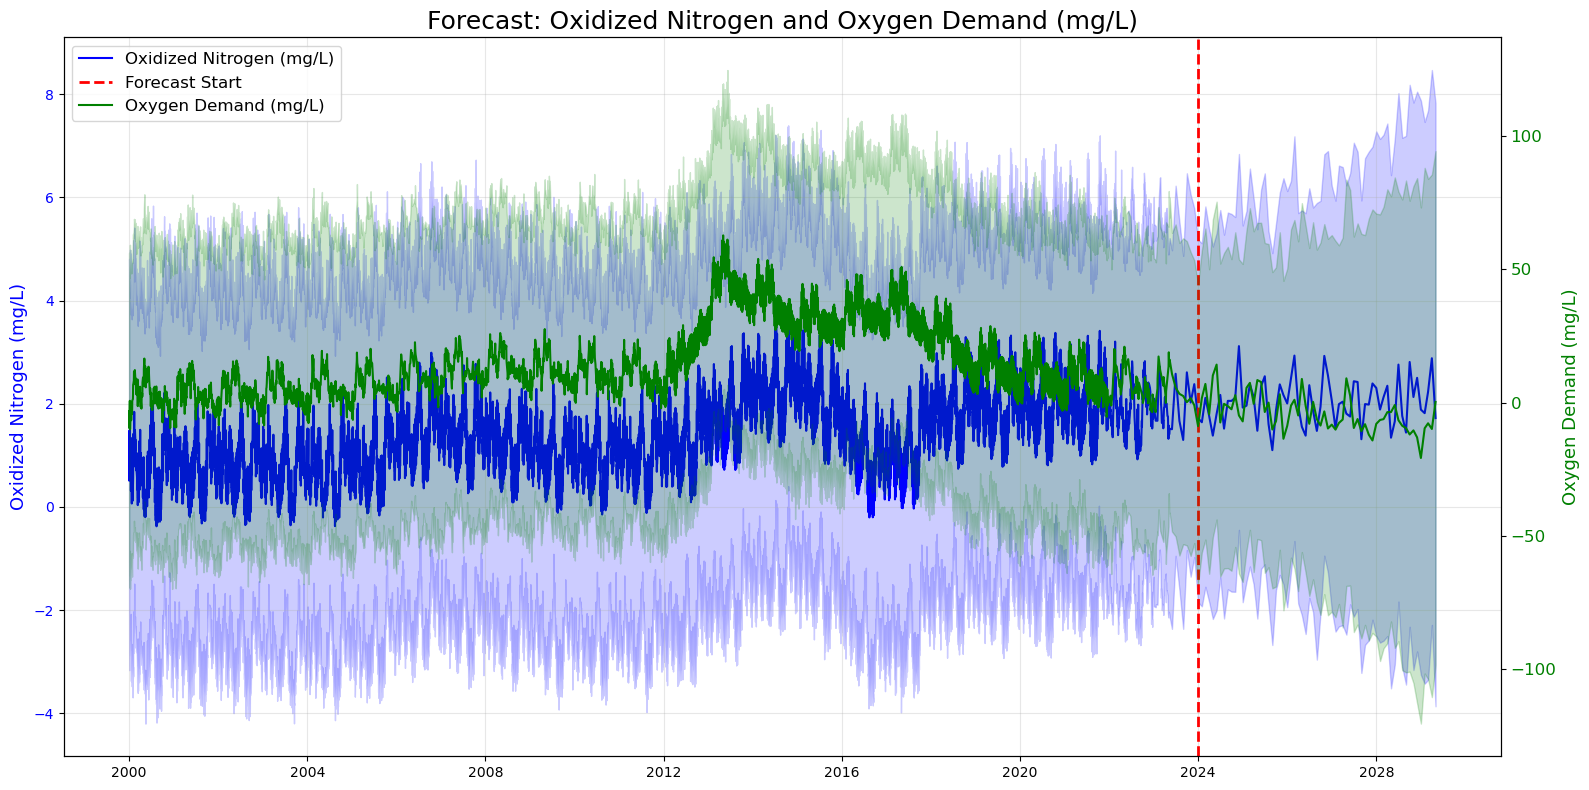

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

#Prepare datasets 
# Assuming nitrate_df and oxygen_df already exist
# and have 'ds' (date) and 'y' (value) columns

#  Train models
model_nitrogen = Prophet()
model_nitrogen.fit(nitrate_df)

model_oxygen = Prophet()
model_oxygen.fit(oxygen_df)

# Create future dataframe 
future_nitrogen = model_nitrogen.make_future_dataframe(periods=72, freq='M')  # 6 years
future_oxygen = model_oxygen.make_future_dataframe(periods=72, freq='M')

forecast_nitrogen = model_nitrogen.predict(future_nitrogen)
forecast_oxygen = model_oxygen.predict(future_oxygen)

# Plot, make the forecasts,  using dual y-axes
fig, ax1 = plt.subplots(figsize=(16, 8))

# Primary y-axis for Nitrogen (blue)
ax1.plot(forecast_nitrogen['ds'], forecast_nitrogen['yhat'], color='blue', label='Oxidized Nitrogen (mg/L)')
ax1.fill_between(forecast_nitrogen['ds'], forecast_nitrogen['yhat_lower'], forecast_nitrogen['yhat_upper'], color='blue', alpha=0.2)
ax1.set_ylabel('Oxidized Nitrogen (mg/L)', color='blue', fontsize=13)
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Oxygen (green)
ax2 = ax1.twinx()
ax2.plot(forecast_oxygen['ds'], forecast_oxygen['yhat'], color='green', label='Oxygen Demand (mg/L)')
ax2.fill_between(forecast_oxygen['ds'], forecast_oxygen['yhat_lower'], forecast_oxygen['yhat_upper'], color='green', alpha=0.2)
ax2.set_ylabel('Oxygen Demand (mg/L)', color='green', fontsize=13)
ax2.tick_params(axis='y', labelcolor='green')

# Add vertical line at forecast start (2024)
latest_data_date = pd.to_datetime('2024-01-01')
ax1.axvline(x=latest_data_date, color='red', linestyle='--', linewidth=2, label='Forecast Start')

# Titles and grid
plt.title('Forecast: Oxidized Nitrogen and Oxygen Demand (mg/L)', fontsize=18)
ax1.grid(alpha=0.3)

# Combined Legend
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc='upper left', fontsize=12)

# Formatting x-axis
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Load Data 
oxygen_df = pd.read_csv('../data/Oxygen_Demand.csv', sep=';')
nitrate_df = pd.read_csv('../data/oxidized_nitrogen.csv', sep=';')
station_metadata = pd.read_csv('../data/GEMStat_station_metadata.csv', sep=';', encoding='ISO-8859-1')

#  Extract Year from Sample.Date 
oxygen_df['Year'] = pd.to_datetime(oxygen_df['Sample.Date'], errors='coerce').dt.year
nitrate_df['Year'] = pd.to_datetime(nitrate_df['Sample.Date'], errors='coerce').dt.year

#Add Country Info via Station Metadata 
# Merge station metadata into oxygen and nitrate datasets to associate country with each record
oxygen_df = pd.merge(
    oxygen_df,
    station_metadata[['GEMS Station Number', 'Country Name']],
    how='left',
    left_on='GEMS.Station.Number',
    right_on='GEMS Station Number'
)

nitrate_df = pd.merge(
    nitrate_df,
    station_metadata[['GEMS Station Number', 'Country Name']],
    how='left',
    left_on='GEMS.Station.Number',
    right_on='GEMS Station Number'
)

# Group by Country & Year and compute averages 
oxygen_avg = oxygen_df.groupby(['Country Name', 'Year'])['Value'].mean().reset_index()
nitrate_avg = nitrate_df.groupby(['Country Name', 'Year'])['Value'].mean().reset_index()

# Merge both average datasets on Country and Year
merged_df = pd.merge(
    oxygen_avg,
    nitrate_avg,
    on=['Country Name', 'Year'],
    suffixes=('_oxygen', '_nitrate')
)

# Rename columns for clarity
merged_df.rename(columns={
    'Country Name': 'Country',
    'Value_oxygen': 'Average Oxygen Demand (mg/L)',
    'Value_nitrate': 'Average Oxidized Nitrogen (mg/L)'
}, inplace=True)

# Save to CSV 
merged_df.to_csv('../data/oxygen_nitrogen_merged.csv', index=False)

# double check
print("Merged CSV created: oxygen_nitrogen_merged.csv")
print(merged_df.head())


/var/folders/tq/7vkyx62523b_ly0hh2lnbrc80000gn/T/ipykernel_84082/547235002.py:4: DtypeWarning:

Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.

/var/folders/tq/7vkyx62523b_ly0hh2lnbrc80000gn/T/ipykernel_84082/547235002.py:5: DtypeWarning:

Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.



Merged CSV created: oxygen_nitrogen_merged.csv
     Country  Year  Average Oxygen Demand (mg/L)  \
0  Argentina  2011                     14.000000   
1  Argentina  2012                      3.625000   
2  Argentina  2013                      8.875000   
3  Argentina  2021                      9.000000   
4    Austria  2014                      2.037671   

   Average Oxidized Nitrogen (mg/L)  
0                          1.865000  
1                          1.928750  
2                          1.645000  
3                          0.657443  
4                          3.376383  
